# Modelo B.

### Importación de librerías.

In [1]:
import numpy as np
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import average_precision_score, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

### Importación de datos.

In [2]:
df = pd.read_csv('datos_sinteticos.csv', sep=";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Eliminando variables no útiles.

In [3]:
df = df.drop(columns=['cliente_id', 'promedio', 'desviacion', 'maximo', 'minimo', 'monto_hora', 'moda_establecimiento', 'cantidad_establecimiento'])
df.head(2)

,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia
0,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal
1,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal


### Separando las variables predictoras de la objetivo.

In [4]:
X = df.drop(columns = ['es_anomalia'])
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [5]:
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=X['tipo_anomalia'])

### Preprocesamiento preliminar de datos.

In [6]:
def convertir_montos(datos):

    # Se genera una serie.
    if isinstance(datos, pd.DataFrame):
        columna = datos.iloc[:, 0]
    else:
        columna = datos

    # Se separan los datos para convertirlos en listas de números.
    montos_separados = (columna.astype("string").str.strip().str.slice(1, -1).str.replace("'", "", regex=False).str.split(r",\s*", expand=True, regex=True))

    return montos_separados.to_numpy(dtype=np.float32)

In [7]:
class EscaladorGlobalSecuencias(BaseEstimator, TransformerMixin):

    # Entrenador del modelo.
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float32)

        self.media_ = X.mean()
        self.desviacion_ = X.std(ddof=0)

        if self.desviacion_ == 0:
            self.desviacion_ = 1.0

        return self

    # Transformador del modelo.
    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - self.media_) / self.desviacion_).astype(np.float32)

In [8]:
pipeline_montos = Pipeline(steps=[
    ("convertir_a_numerico", FunctionTransformer(convertir_montos, validate=False)),
    ("transformacion_logaritmica", FunctionTransformer(np.log1p, validate=False)),
    ("normalizacion_global", EscaladorGlobalSecuencias())
    ], verbose=False)

## LSTM.

### Separación del conjunto de entrenamiento y de validación.

In [9]:
lstm_train_x, lstm_val_x, lstm_train_y, lstm_val_y = train_test_split(X_lstm_train, y_lstm_train, test_size=0.20, random_state=0, stratify=y_lstm_train)

### Transformación de datos.

In [10]:
# Preprocesando los datos.
lstm_train_x = pipeline_montos.fit_transform(lstm_train_x['montos'])
lstm_val_x = pipeline_montos.transform(lstm_val_x['montos'])
lstm_test_x = pipeline_montos.transform(X_lstm_test['montos'])

# Conv1D espera (n, 30, 1).
lstm_train_x = lstm_train_x.astype(np.float32)[..., np.newaxis]
lstm_val_x = lstm_val_x.astype(np.float32)[..., np.newaxis]
lstm_test_x = lstm_test_x.astype(np.float32)[..., np.newaxis]

# Cambiando la estructura de las etiquetas
lstm_train_y = np.asarray(lstm_train_y, dtype=np.float32).reshape(-1)
lstm_val_y = np.asarray(lstm_val_y, dtype=np.float32).reshape(-1)
lstm_test_y = np.asarray(y_lstm_test, dtype=np.float32).reshape(-1)

### Arquitectura de datos.

In [11]:
tf.keras.utils.set_random_seed(0)

modelo_lstm = tf.keras.Sequential([

    # Capa de entrada.
    tf.keras.layers.Input(shape=(30, 1), name="secuencia_montos"),

    # Primer bloque.
    tf.keras.layers.LSTM(units=64, activation="tanh", recurrent_activation="sigmoid", return_sequences=True,
                         dropout=0.0, recurrent_dropout=0.0, name="lstm_1"),
    tf.keras.layers.LayerNormalization(name="normalizacion_lstm_1"),
    tf.keras.layers.Dropout(rate=0.1, name="dropout_1"),

    # Segundo bloque.
    tf.keras.layers.LSTM(units=32, activation="tanh", recurrent_activation="sigmoid", return_sequences=False,
                         dropout=0.0, recurrent_dropout=0.0, name="lstm_2"),
    tf.keras.layers.Dense(units=32, activation="relu", name="capa_densa"),
    #tf.keras.layers.Dropout(rate=0.1, name="dropout_2"),

    # Capa densa.
    tf.keras.layers.Dense(units=1, activation="sigmoid", name="score_fraude")

    ], name="lstm_montos"
)

### Compilacón del modelo.

In [12]:
modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
             tf.keras.metrics.Precision(name="precision", thresholds=0.5),
             tf.keras.metrics.Recall(name="recall", thresholds=0.5),
             tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
             tf.keras.metrics.AUC(name="pr_auc", curve="PR")])

modelo_lstm.summary()

Model: "lstm_montos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion_lstm_1            │ (None, 30, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ score_fraude (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,529 (119.25 KB)

 Trainable params: 30,529 (119.25 KB)

 Non-trainable params: 0 (0.00 B)

### Balanceo de clases.

In [13]:
clases = np.unique(lstm_train_y)
pesos = compute_class_weight(class_weight="balanced", classes=clases, y=lstm_train_y)
class_weight = {int(clase): float(peso) for clase, peso in zip(clases, pesos)}

print("Pesos de las clases:", class_weight)

Pesos de las clases: {0: 0.5559512847686722, 1: 4.968172643999379}


### Entrenamiento del modelo.

In [14]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, min_delta=1e-4, restore_best_weights=True, verbose=1),
             tf.keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=3, min_delta=1e-4, min_lr=1e-6, verbose=1)]

historial_lstm = modelo_lstm.fit(
    lstm_train_x,
    lstm_train_y,
    validation_data=(lstm_val_x, lstm_val_y),
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5357 - loss: 0.6917 - pr_auc: 0.1148 - precision: 0.1096 - recall: 0.5071 - roc_auc: 0.5342 - val_accuracy: 0.7661 - val_loss: 0.6392 - val_pr_auc: 0.1316 - val_precision: 0.1298 - val_recall: 0.2323 - val_roc_auc: 0.5505 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6704 - loss: 0.6635 - pr_auc: 0.1951 - precision: 0.1485 - recall: 0.4805 - roc_auc: 0.6179 - val_accuracy: 0.8562 - val_loss: 0.5806 - val_pr_auc: 0.2753 - val_precision: 0.2907 - val_recall: 0.2981 - val_roc_auc: 0.6395 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8150 - loss: 0.6157 - pr_auc: 0.3251 - precision: 0.2541 - recall: 0.4330 - roc_auc: 0.6768 - val_accuracy: 0.8745 - val_loss: 0.5545 - val_pr_auc: 0.3461 - val_precision: 0.3708 - val_recall: 0.3547 - val_roc_auc: 0.6657 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accu

### Medición del desempeño en conjunto de prueba.

In [15]:
resultados = modelo_lstm.evaluate(lstm_test_x, lstm_test_y, batch_size=256, verbose=0, return_dict=True)

for metrica, valor in resultados.items():
    print(f"{metrica}: {valor:.4f}")

accuracy: 0.9147
loss: 0.5089
pr_auc: 0.4697
precision: 0.6212
recall: 0.3910
roc_auc: 0.6974


### Guardando el modelo y el pipeline.

In [16]:
# Modelo
modelo_lstm.save("modelo_b.keras")

# Pipeline
joblib.dump(pipeline_montos, "pipeline_b.joblib")

['pipeline_b.joblib']

### Prediciendo con el modelo.

In [20]:
y_prob = modelo_lstm.predict(lstm_test_x, batch_size=32, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

### Métricas del modelo.

In [21]:
print('Reporte de clasificación')
print(classification_report(lstm_test_y, y_pred))
pr_auc = average_precision_score(lstm_test_y, y_prob)
print(f"PR-AUC en prueba: {pr_auc:.4f}")

Reporte de clasificación
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95     17987
         1.0       0.62      0.39      0.48      2013

    accuracy                           0.91     20000
   macro avg       0.78      0.68      0.72     20000
weighted avg       0.90      0.91      0.91     20000

PR-AUC en prueba: 0.4706


### Matriz de confusión.

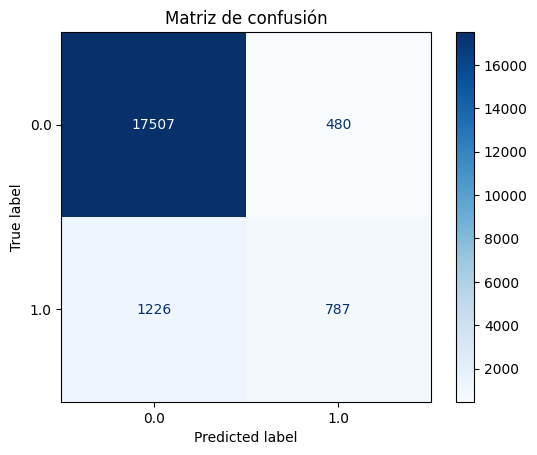

In [22]:
ConfusionMatrixDisplay.from_predictions(lstm_test_y, y_pred, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()